<a href="https://colab.research.google.com/github/JeffersonRodrigues9/Projetos-em-Machine-Learning/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00


[SISTEMA] Carregar os pesos da Rede Neural (YOLOv8) ...

--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---
 -> Detecção: PERSON | Confiança: 85.9%
 -> Detecção: CUP | Confiança: 79.7%
 -> Detecção: PERSON | Confiança: 72.6%
 -> Detecção: PERSON | Confiança: 72.5%
 -> Detecção: PERSON | Confiança: 67.6%
 -> Detecção: PERSON | Confiança: 66.7%
 -> Detecção: PERSON | Confiança: 64.3%
 -> Detecção: POTTED PLANT | Confiança: 63.8%
 -> Detecção: PERSON | Confiança: 59.8%
 -> Detecção: CHAIR | Confiança: 56.9%
 -> Detecção: CHAIR | Confiança: 52.8%
 -> Detecção: CHAIR | Confiança: 52.1%
 -> Detecção: BOOK | Confiança: 47.7%
 -> Detecção: CHAIR | Confiança: 45.0%
 -> Detecção: LAPTOP | Confiança: 43.0%
 -> Detecção: LAPTOP | Confiança: 42.7%
 -> Detecção: LAPTOP | Confiança: 41.0%
 -> Detecção: LAPTOP | Confiança: 40.3%
 -> Detecção: BOOK | Confiança: 39.2%
 -> Detecção: CHAIR | Confiança: 35.4%
 -> Detecção: CHAIR | Confiança: 31.8%
 -> Detecção: BOOK | Confiança: 30.5%
 -> Detecção: CUP | C

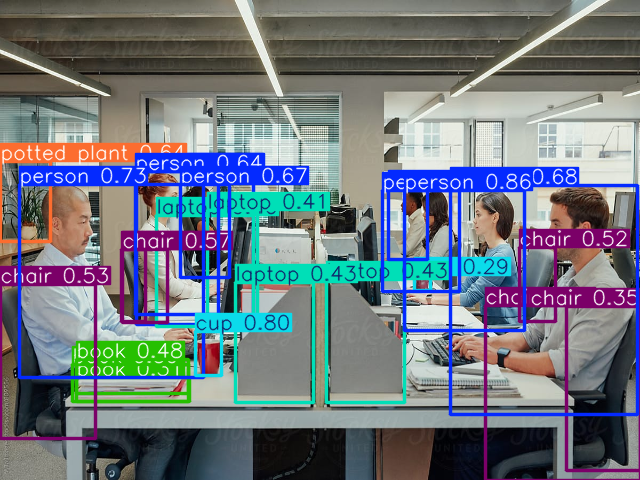

In [17]:
# DETECÇÃO DE MÚLTIPLOS OBJETOS COM YOLOv8
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Carregar o modelo YOLOv8 pré-treinado
print("[SISTEMA] Carregar os pesos da Rede Neural (YOLOv8) ...")
modelo_yolo = YOLO('yolov8n.pt')

# 2. Ler a Imagem estática
imagem_bruta = cv2.imread('escritorio.jpg')

# 3. Redimensionar para um tamanho padrão
imagem_redimensionada = cv2.resize(imagem_bruta,(640, 480))

# 4. Limpar a console
resultados = modelo_yolo(imagem_redimensionada, verbose=False)


# 5. Desenhar os retângulos coloridos de forma automática / Escrever o nome da classe (ex: 'person', 'chair')
imagem_final_ia = resultados[0].plot()

print("\n--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---")
for caixa in resultados[0].boxes:
    #Extrair o ID da classe e traduzir para o nome do objeto
    classe_id = int(caixa.cls[0])
    nome_objeto = modelo_yolo.names[classe_id]

    # Extrair o score da confiança (probabilidade matemática de acerto da IA)
    confianca = float(caixa.conf[0]) * 100

    print(f" -> Detecção: {nome_objeto.upper()} | Confiança: {confianca:.1f}%")

# 6. Exibir o painel visual final para a validação
print("\n--- Resultado do monitoramento por Inteligência Artificial ---")
cv2_imshow(imagem_final_ia)